# Librerías

In [ ]:
# Análisis exploratorio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Preparación de los datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas
from sklearn.metrics import silhouette_score,silhouette_samples

# Base de datos: variedades de trigo
https://www.kaggle.com/datasets/sudhanshu2198/wheat-variety-classification
## Información del conjunto de datos
El conjunto de datos comprende granos de trigo pertenecientes a tres variedades diferentes: Kama, Rosa y Canadian, con 70 elementos cada una. Todos estos parámetros fueron de valor real continuo.
## Información de las variables
Para construir los datos, se midieron siete variables geométricas de los granos de trigo: área A, perímetro P, compactibilidad $C = 4pi*A/P^2$, longitud del grano, ancho del grano, coeficiente de asimetría y longitud del surco del grano.


In [ ]:
!gdown 1J8I0tGdrTHXjGFM51pxMvO_kBJoIeOm1

Downloading...
From: https://drive.google.com/uc?id=1J8I0tGdrTHXjGFM51pxMvO_kBJoIeOm1
To: /content/wheat.csv
100% 10.0k/10.0k [00:00<00:00, 26.3MB/s]


In [ ]:
df = pd.read_csv("wheat.csv")

# Estructura

In [ ]:
df.head()

,area,perimeter,compactness,length,width,asymmetry coefficient,groove length,category
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1.0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1.0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1.0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1.0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1.0


In [ ]:
# Chequeamos que datos tenemos y si hay nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   210 non-null    float64
 1   perimeter              210 non-null    float64
 2   compactness            210 non-null    float64
 3   length                 210 non-null    float64
 4   width                  210 non-null    float64
 5   asymmetry coefficient  210 non-null    float64
 6   groove length          210 non-null    float64
 7   category               210 non-null    float64
dtypes: float64(8)
memory usage: 13.3 KB


In [ ]:
df.describe()

,area,perimeter,compactness,length,width,asymmetry coefficient,groove length,category
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [ ]:
target_names = {
1:'Kama',
2:'Rosa',
3:'Canadian'
}

df['category'] = df['category'].map(target_names)
df["category"].value_counts()

,count
category,
Kama,70
Rosa,70
Canadian,70


# Conjunto de prueba

In [ ]:
train, test = train_test_split(df, test_size=0.2, stratify=df['category'],
                               random_state=42)

# Análisis exploratorio

In [ ]:
weat = train.copy(deep=True)

## Matriz de correlación

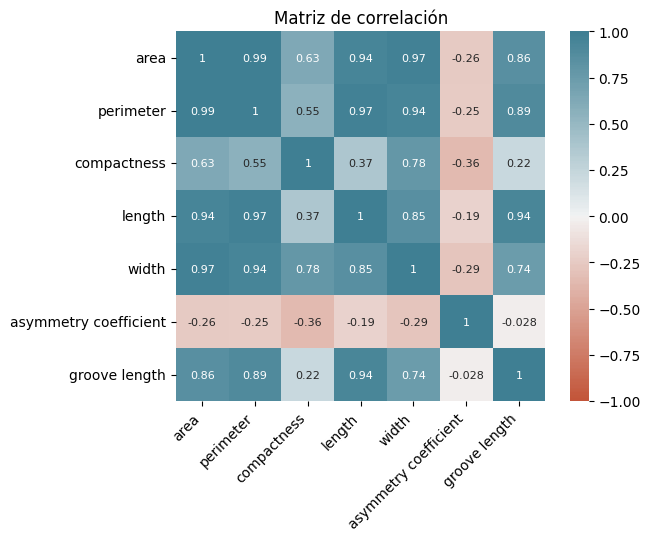

In [ ]:
corr = weat.drop(columns='category').corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 8}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

## Graficas de distribución



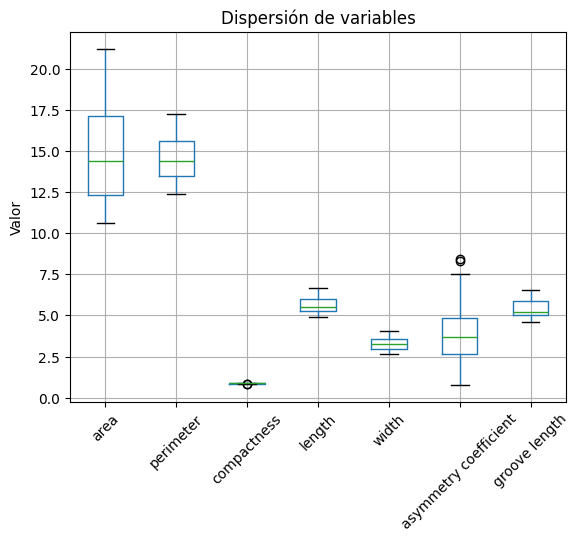

In [ ]:
weat.boxplot(rot=45)
plt.title('Dispersión de variables')
plt.ylabel('Valor')
plt.show()

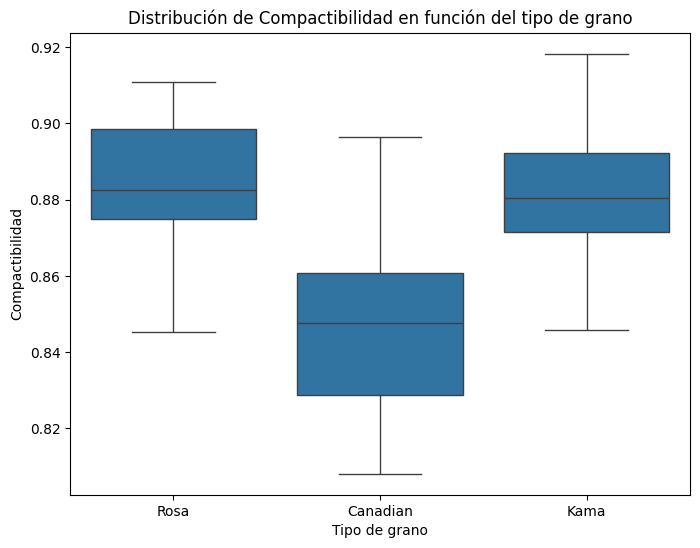

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='category', y='compactness', data=weat)
plt.title('Distribución de Compactibilidad en función del tipo de grano')
plt.xlabel('Tipo de grano')
plt.ylabel('Compactibilidad')
plt.show()

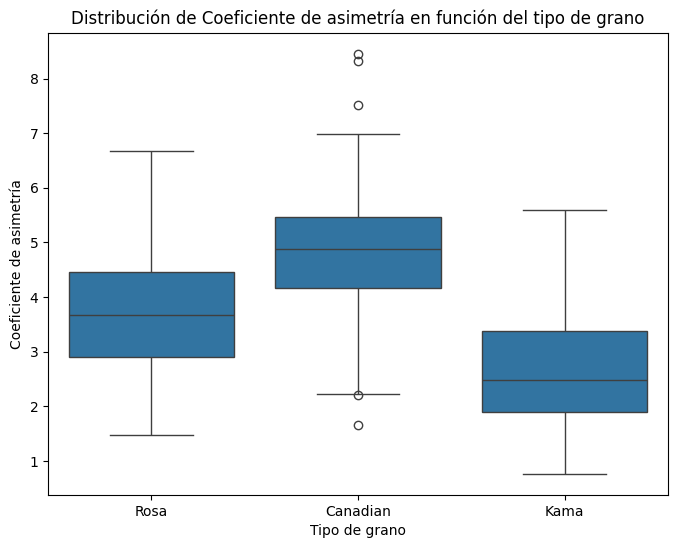

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='category', y='asymmetry coefficient', data=weat)
plt.title('Distribución de Coeficiente de asimetría en función del tipo de grano')
plt.xlabel('Tipo de grano')
plt.ylabel('Coeficiente de asimetría')
plt.show()

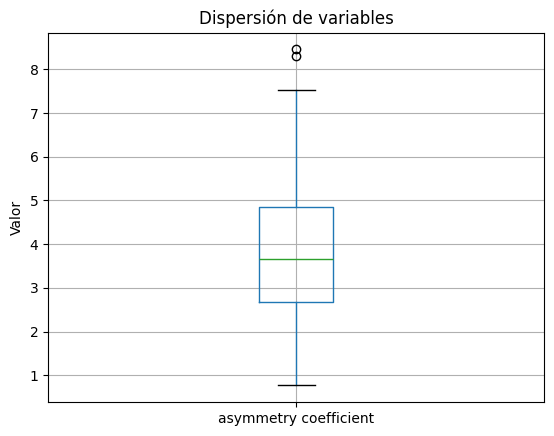

In [ ]:
weat.boxplot(column='asymmetry coefficient')
plt.title('Dispersión de variables')
plt.ylabel('Valor')
plt.show()

## Gráfica de dispersión

In [ ]:
fig = px.scatter_3d(weat, x='area', y='length', z='asymmetry coefficient',
                    #color='category',
                    title='Dispersión de las variedades de trigo')
fig.show()

# Preparación de los datos

## Remocion de Outliers
Luego de verificar que el coeficiente de asimetría por tipo de grano contiene valores atípicos procedemos a removerlos

In [ ]:
# IQR
# Columnas con outliers
outliers_col = ['asymmetry coefficient']
# limite mayor y menor
outliers = weat.copy(deep=True)
for col in outliers_col:
    Q1 = weat[col].quantile(0.25)
    Q3 = weat[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    # Arreglo de booleanos que indican las filas con outliers
    upper_array = np.where(weat[col] >= upper)[0]
    lower_array = np.where(weat[col] <= lower)[0]

    # Reemoción de outliers
    outliers.drop(index=upper_array, inplace=True)
    outliers.drop(index=lower_array, inplace=True)

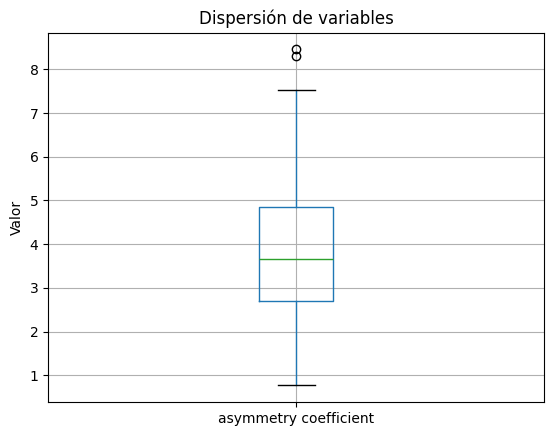

In [ ]:
outliers.boxplot(column='asymmetry coefficient')
plt.title('Dispersión de variables')
plt.ylabel('Valor')
plt.show()

In [ ]:
# Separo observaciones de etiquetas
X = outliers.drop(['category'], axis=1)
y = outliers['category']
X.head()

,area,perimeter,compactness,length,width,asymmetry coefficient,groove length
108,19.94,16.92,0.8752,6.675,3.763,3.252,6.550
202,11.18,12.72,0.8680,5.009,2.810,4.051,4.828
194,12.11,13.27,0.8639,5.236,2.975,4.132,5.012
94,18.36,16.52,0.8452,6.666,3.485,4.933,6.448
137,15.57,15.15,0.8527,5.920,3.231,2.640,5.879


In [ ]:
# Eligo 3 variables para poder visualizar en 3 dimensiones
column_names = ["area", "length", "asymmetry coefficient"]
X_reducido = X[column_names]
X_reducido.head()

,area,length,asymmetry coefficient
108,19.94,6.675,3.252
202,11.18,5.009,4.051
194,12.11,5.236,4.132
94,18.36,6.666,4.933
137,15.57,5.920,2.640


## Escalado
[Documentación de StandardScaler en sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler)

In [ ]:
# Creo el objeto scaler que calcula la media y la desviación estándar de los
# datos y luego aplica la transformación de estandarización.
scaler = StandardScaler().set_output(transform="pandas")
X_std = scaler.fit_transform(X_reducido)
X_std.head()

,area,length,asymmetry coefficient
108,1.777624,2.409620,-0.340083
202,-1.276644,-1.437659,0.190182
194,-0.952390,-0.913450,0.243938
94,1.226740,2.388836,0.775531
137,0.253976,0.666105,-0.746243


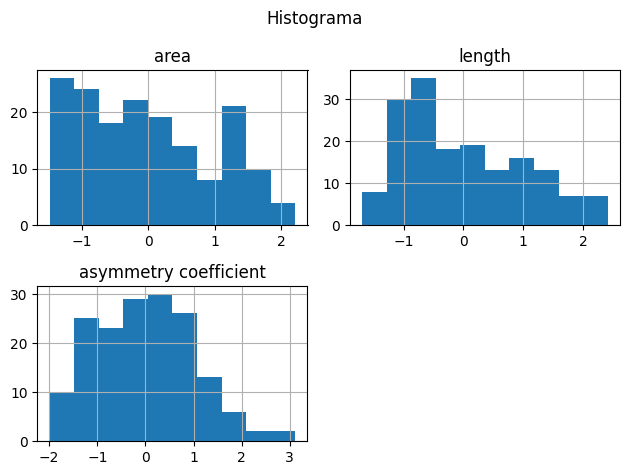

In [ ]:
X_std.hist()
plt.suptitle('Histograma')
plt.tight_layout()
plt.show()

## K means

### Selección de k
El objetivo es identificar un punto en el gráfico donde la disminución en la suma de las distancias intraclúster (también conocida como inercia) comienza a disminuir de manera significativamente más lenta. Este punto se denomina "codo" y sugiere el número adecuado de clústeres para el conjunto de datos.

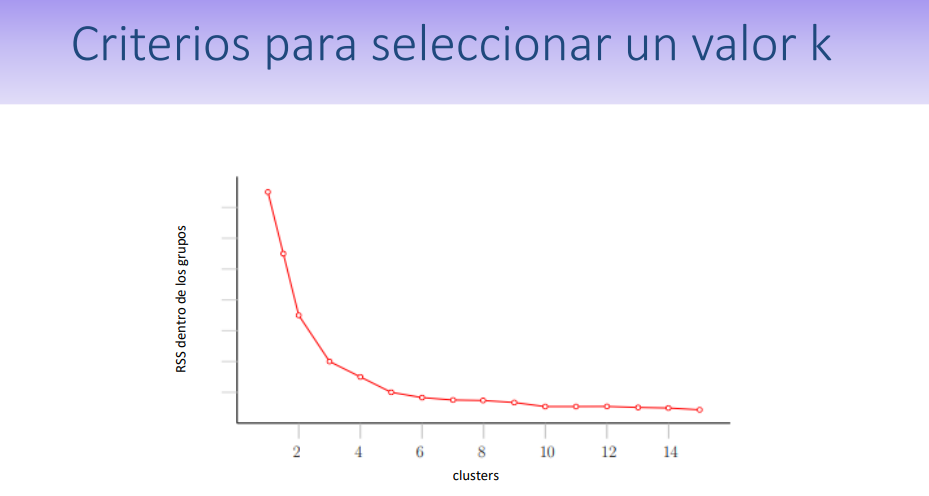

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

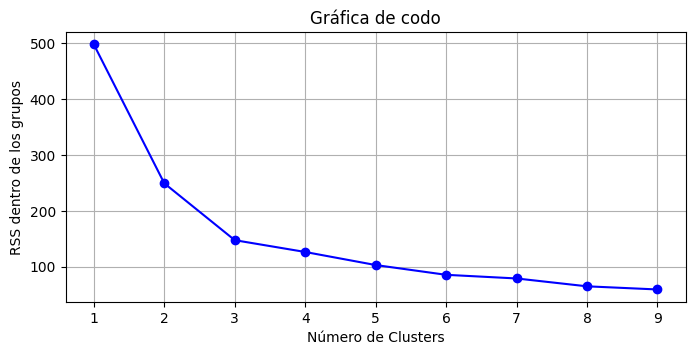

In [ ]:
Nc = range(1, 10)
kmeans = [KMeans(n_clusters=k, random_state=42).fit(X_std) for k in Nc]

# La suma de residuos cuadrados intra grupos de kMeans en sklearn se guarda en
# el atributo inertia
inertias = [model.inertia_ for model in kmeans]

plt.figure(figsize=(8, 3.5))
plt.plot(Nc,inertias, "bo-")
plt.xlabel('Número de Clusters')
plt.ylabel('RSS dentro de los grupos')
plt.title('Gráfica de codo')
plt.grid()
plt.show()

### Aplicamos el modelo



In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42,
                init='k-means++', n_init=5, algorithm='lloyd')
kmeans.fit(X_std) #Entrenamos el modelo
y_pred = kmeans.predict(X_std)

In [ ]:
np.array_equal(y_pred, kmeans.labels_)

True

In [ ]:
# El metodo labels_ nos da a que cluster corresponde cada observacion
X_std['Etiquetas KMeans'] = kmeans.labels_
X_std['Etiquetas KMeans'] = X_std['Etiquetas KMeans'].astype('category')
X_std.head()

,area,length,asymmetry coefficient,Etiquetas KMeans
108,1.777624,2.409620,-0.340083,0
202,-1.276644,-1.437659,0.190182,1
194,-0.952390,-0.913450,0.243938,1
94,1.226740,2.388836,0.775531,0
137,0.253976,0.666105,-0.746243,2


In [ ]:
np.set_printoptions(precision=6)
kmeans.cluster_centers_
# caracteristicas normalizadas que tendria el centroide de ese cluster.

array([[ 1.201065,  1.204128, -0.008554],
       [-1.032448, -0.912562,  0.930495],
       [-0.209683, -0.318201, -0.812123]])

**Desafío**: Verificar si los centroides se corresponden con el valor medio de los grupos creados.

In [ ]:
fig = px.scatter_3d(X_std, x='area', y='length', z='asymmetry coefficient',
                    color='Etiquetas KMeans',
                    title='Dispersión de las variedades de trigo (K-means)')
fig.show()

In [ ]:
fig = px.scatter_3d(X_std, x='area', y='length', z='asymmetry coefficient',
                    color=y,
                    title='Dispersión de las variedades de trigo (original)')
fig.show()

### Verificación con datos de prueba

In [ ]:
# Elijo las mismas columnas del entrenamiento
X_tst = test[column_names]
X_tst_std = scaler.transform(X_tst) # Normalizo con escaler entrenado
y_tst = test['category']
# Predicción de clusters
y_tst_pred = kmeans.predict(X_tst_std)
y_tst_pred = pd.Series(y_tst_pred).astype('category')

In [ ]:
# Grafico los datos de test con los clusters
fig = px.scatter_3d(X_tst_std, x='area', y='length', z='asymmetry coefficient',
                    color=y_tst_pred,
                    title='Dispersión de las variedades de trigo (k-means)')

fig.show()

In [ ]:
fig = px.scatter_3d(X_tst_std, x='area', y='length', z='asymmetry coefficient',
                    color=y_tst,
                    title='Dispersión de las variedades de trigo (original)')

fig.show()

**Desafío**: verificar en que puntos no coinciden los clusters de Kmeans con las etiquetas verdaderas.

## Clustering jerarquico

In [ ]:
# Importa la función linkage de SciPy para realizar el clustering jerárquico
Z = linkage(X_std, "ward")

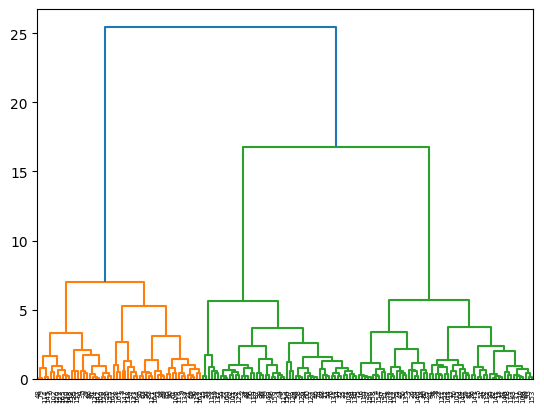

In [ ]:
# Dibuja un dendrograma para visualizar el resultado del clustering jerárquico
dendrogram(Z)
plt.show()

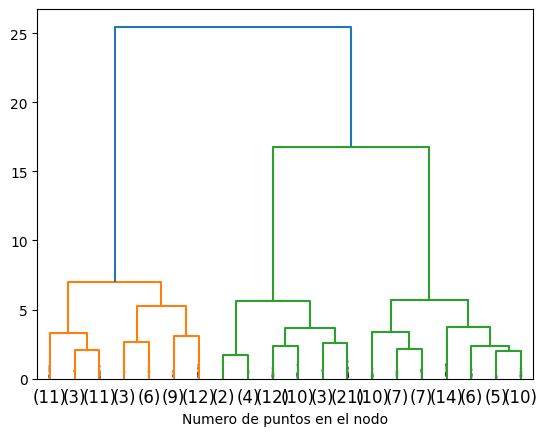

In [ ]:
# Dibuja un dendrograma truncado (solo muestra las últimas p hojas)
dendrogram(Z,  truncate_mode = 'lastp', p = 20, show_leaf_counts = True,
           show_contracted = True)
plt.axhline(y=110, c='k', linestyle='dashed')
plt.xlabel("Numero de puntos en el nodo")
plt.show()

In [ ]:
from scipy.spatial.distance import cdist

distancias=[]
for i in range(1, 10):
    clustering = AgglomerativeClustering(n_clusters=i) # Aplica clustering jerárquico con i clusters
    clustering.fit(X_std)

    # Calcula la matriz de distancias por pares entre los puntos
    pairwise_distances = cdist(X_std, X_std, 'euclidean')

    # Calcula la distancia total dentro de los clusters
    distancia_total = 0
    for j in range(i):
        cluster_indices = np.where(clustering.labels_ == j)
        # Encuentra los índices de los puntos en el cluster j
        distancia_total += pairwise_distances[cluster_indices][:, cluster_indices].sum()
        # Suma las distancias dentro del cluster


    distancias.append(distancia_total)
    # Almacena la distancia total para el número de clusters i

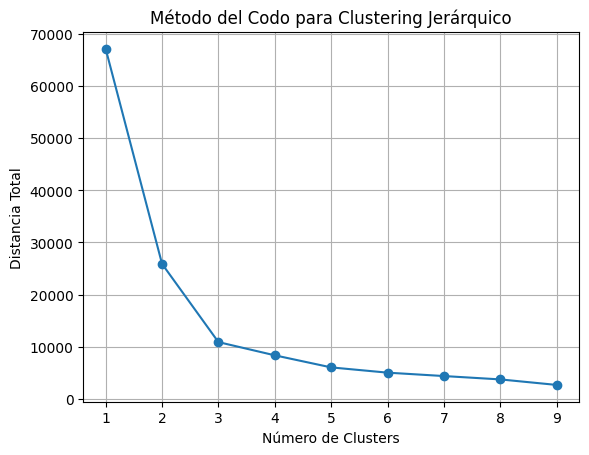

In [ ]:
# Grafica la distancia total en función del número de clusters
plt.plot(range(1, 10), distancias, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Distancia Total')
plt.title('Método del Codo para Clustering Jerárquico')
plt.grid()
plt.show()

In [ ]:
n_clusters = 3
clustering = AgglomerativeClustering(n_clusters=n_clusters)

cluster_assignments = clustering.fit_predict(X_std)
# Asigna los clusters a los datos

X_std['Etiquetas jerarquico'] = cluster_assignments
# Añade la columna con el cluster asignado a cada punto

X_std.head()

,area,length,asymmetry coefficient,Etiquetas KMeans,Etiquetas jerarquico
108,1.777624,2.409620,-0.340083,0,0
202,-1.276644,-1.437659,0.190182,1,2
194,-0.952390,-0.913450,0.243938,1,2
94,1.226740,2.388836,0.775531,0,0
137,0.253976,0.666105,-0.746243,2,1


KeyError: 'Cluster'

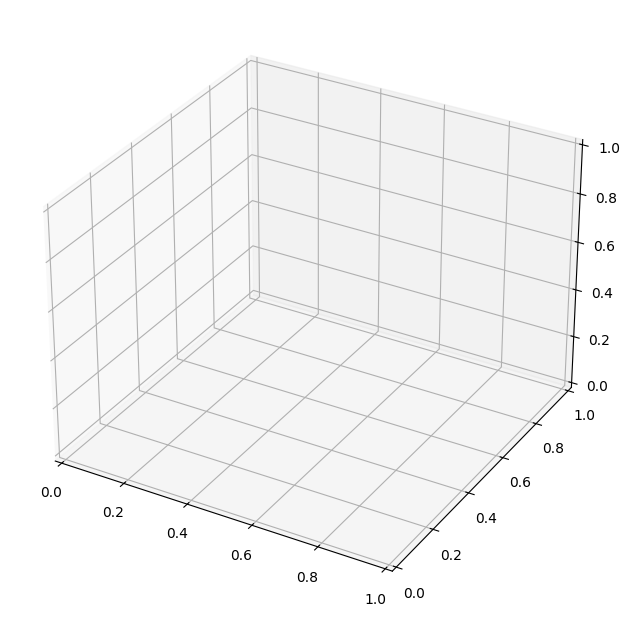

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = Axes3D(fig, auto_add_to_figure=False) # Crea un gráfico 3D
fig.add_axes(ax)
labels = np.unique(X_std['Cluster']) # Obtiene los clusters únicos
palette = sns.color_palette("husl", len(labels)) # Define una paleta de colores
for label, color in zip(labels, palette):
  df1 = X_std[X_std['Cluster'] == label]
  ax.scatter(df1['area'], df1['length'], df1['asymmetry coefficient'],
             s=40, marker='o', color=color, alpha=1, label=label)

In [ ]:
# Calcula el coeficiente de Silhouette promedio
silhouette_score(X_std, cluster_assignments)

## DBSCAN y HDBSCAN

In [ ]:
!pip install hdbscan

In [ ]:
from sklearn.cluster import DBSCAN
from hdbscan import HDBSCAN

###Parametros DBSCAN (Density-Based Spatial Clustering of Applications with Noise):

eps (Epsilon): Este parámetro controla la distancia máxima entre dos muestras para que una sea considerada parte del mismo clúster. En otras palabras, establece la distancia máxima entre puntos vecinos que se agruparán juntos. Un valor pequeño de eps puede hacer que el algoritmo encuentre más clústeres, mientras que un valor grande puede fusionar más puntos en un solo clúster.

min_samples: Este parámetro define el número mínimo de muestras (puntos de datos) en un vecindario para que un punto sea considerado núcleo (core point). Los puntos núcleo son aquellos que tienen al menos min_samples puntos dentro de una distancia de eps. Los puntos que no son núcleo, pero están dentro del vecindario de un punto núcleo, se consideran puntos límite o de borde.



In [ ]:
# Aplico DBSCAN con parámetros eps y min_samples
dbscan = DBSCAN(eps=0.6, min_samples=12)
dbscan_labels = dbscan.fit_predict(X_std)


# Cuenta el número de clusters identificados, excluyendo el ruido (-1)
groups = len(set(dbscan_labels))
count_noise = (1 if -1 in dbscan_labels else 0)

print("Número de clústeres identificados por DBSCAN:", groups - count_noise)

In [ ]:
count_noise

###HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise):

min_cluster_size: Este parámetro establece el tamaño mínimo del clúster. Los clústeres con menos puntos que min_cluster_size no se considerarán como clústeres válidos y se etiquetarán como ruido (-1 en las etiquetas). Aumentar este valor tiende a producir menos clústeres.

In [ ]:
# Aplica HDBSCAN con parámetro min_cluster_size

hdbscan = HDBSCAN(min_cluster_size=5)
hdbscan_labels = hdbscan.fit_predict(X_std)

# Cuenta el número de clusters identificados, excluyendo el ruido (-1)
groups = len(set(hdbscan_labels))
count_noise = (1 if -1 in hdbscan_labels else 0)

print("Número de clústeres identificados por HDBSCAN:", groups - count_noise)

In [ ]:
count_noise

In [ ]:
X_std['Cluster DBSCAN'] = dbscan_labels
X_std['Cluster HDBSCAN'] = hdbscan_labels

In [ ]:
X_std

In [ ]:
# Grafico los clusters obtenidos por DBSCAN
fig = plt.figure(figsize=(10, 6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

# Obtengo los valores únicos de los clústeres (incluyendo el ruido, que es -1)
labels = np.unique(X_std['Cluster DBSCAN'])

# Creo una paleta de colores
palette = sns.color_palette("husl", len(labels))

# Recorro los clústeres y asigno un color a cada uno
for label, color in zip(labels, palette):
    df1 = X_std[X_std['Cluster DBSCAN'] == label]

    # Defino la etiqueta para el ruido
    if label == -1:
        cluster_label = 'Ruido'
    else:
        cluster_label = f'Clúster {label}'

    # Grafico los puntos para cada clúster
    ax.scatter(df1['area'], df1['length'], df1['asymmetry coefficient'], s=40,
               marker='o', color=color, alpha=1, label=cluster_label)

# Etiquetas de los ejes
ax.set_xlabel('Area')
ax.set_ylabel('Length')
ax.set_zlabel('Asymmetry Coefficient')

# Muestra la leyenda
ax.legend(loc='best')

plt.show()

In [ ]:
# Grafico los clusters obtenidos por HDBSCAN
fig = plt.figure(figsize=(10, 6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

# Obtengo los valores únicos de los clústeres (incluyendo el ruido, que es -1)
labels = np.unique(X_std['Cluster HDBSCAN'])

# Creo una paleta de colores
palette = sns.color_palette("husl", len(labels))

# Recorro los clústeres y asigno un color a cada uno
for label, color in zip(labels, palette):
    df1 = X_std[X_std['Cluster HDBSCAN'] == label]

    # Defino la etiqueta para el ruido
    if label == -1:
        cluster_label = 'Ruido'
    else:
        cluster_label = f'Clúster {label}'

    # Grafico los puntos para cada clúster
    ax.scatter(df1['area'], df1['length'], df1['asymmetry coefficient'], s=40,
               marker='o', color=color, alpha=1, label=cluster_label)

# Etiquetas de los ejes
ax.set_xlabel('Area')
ax.set_ylabel('Length')
ax.set_zlabel('Asymmetry Coefficient')

# Muestra la leyenda
ax.legend(loc='best')

plt.show()

#Validacion

##K-means

###Gap statistics

In [ ]:
def calculate_intra_cluster_dispersion(X, k):
    kmeans = KMeans(n_clusters=k) # Aplica K-means
    kmeans.fit(X_std)
    return kmeans.inertia_ # Retorna la suma de distancias al centroide

In [ ]:
gaps = []
max_k = 10

# Calcula el Gap Statistic para determinar el número óptimo de clusters

for k in range(1, max_k + 1):
    # Calculo la inercia real sobre mis datos reales
    real_inertia = calculate_intra_cluster_dispersion(X_std, k)
    #Calculo la inercia de datos aleatorios con la misma estructura que mis datos originales
    inertia_list = []
    for _ in range(10):
      random_data = np.random.rand(*X_std.shape)
      intra_cluster_dispersion = calculate_intra_cluster_dispersion(random_data, k)
      inertia_list.append(intra_cluster_dispersion)

    reference_inertia = np.mean(inertia_list)

    #Aplico la funcion de gap
    gap = np.log(reference_inertia) - np.log(real_inertia)
    gaps.append(gap)

#se selecciona el valor de k (número de clusters) que maximiza el Gap Statistic.
optimal_k = np.argmax(gaps) + 1


In [ ]:
print("Número óptimo de clusters según el Gap Statistic:", optimal_k)

plt.figure(figsize=(8, 3))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para determinar el número de clusters')
plt.grid()
plt.show()

###Coeficiente de Silhouette

In [ ]:
def calculate_silhouette(X_scaled, k):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, labels)  # Calcula el coeficiente de Silhouette
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    return silhouette_avg, sample_silhouette_values

max_k = 10

silhouette_scores = []
for k in range(2, max_k + 1):
    silhouette_avg, _ = calculate_silhouette(X_std, k)
    silhouette_scores.append(silhouette_avg)

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette para determinar el número óptimo de clusters')
plt.show()

## Clustering jerárquico

###Gap Statistics

In [ ]:
def calculate_intra_cluster_dispersion(X_scaled, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X_scaled)

    # Calcula los centroides de los clústeres como la media de los puntos dentro de cada clúster
    centroids = np.array([np.mean(X_scaled[labels == i], axis=0) for i in range(k)])

    # Calcula la dispersión intraclúster sumando las distancias al cuadrado entre los puntos y sus centroides
    # np.linalg.norm calcula la norma (distancia euclidiana) entre los puntos y el centroide correspondiente
    intra_cluster_dispersion = np.sum(np.linalg.norm(X_scaled[labels] - centroids[labels], axis=1)**2)
    return intra_cluster_dispersion


In [ ]:
def calculate_intra_cluster_dispersion(X, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X)

    # Convert X to a NumPy array for integer-based indexing
    X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X

    # Calcula los centroides de los clústeres como la media de los puntos dentro de cada clúster
    centroids = np.array([np.mean(X_np[labels == i], axis=0) for i in range(k)])

    # Calcula la dispersión intraclúster sumando las distancias al cuadrado entre los puntos y sus centroides
    # np.linalg.norm calcula la norma (distancia euclidiana) entre los puntos y el centroide correspondiente
    intra_cluster_dispersion = np.sum(np.linalg.norm(X_np[labels] - centroids[labels], axis=1)**2)
    return intra_cluster_dispersion

gaps = []
max_k = 10
for k in range(1, max_k + 1):
    # Calcula la dispersión intraclúster en los datos reales para 'k' clústeres
    X_std_numerical = X_std.select_dtypes(include=np.number)
    real_inertia = calculate_intra_cluster_dispersion(X_std_numerical, k, linkage='ward')

    inertia_list = []
    for _ in range(10):
      random_data = np.random.rand(*X_std_numerical.shape)
      intra_cluster_dispersion = calculate_intra_cluster_dispersion(random_data, k)
      inertia_list.append(intra_cluster_dispersion)

    reference_inertia = np.mean(inertia_list)

    gap = np.log(reference_inertia) - np.log(real_inertia)
    gaps.append(gap)

optimal_k = np.argmax(gaps) + 1

In [ ]:
print("Número seleccionado de clusters según el Gap Statistic:", optimal_k)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para determinar el número óptimo de clusters (Clustering Jerárquico)')
plt.show()

###Coeficiente de Silhouette

In [ ]:
def calculate_silhouette(X_scaled, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    return silhouette_avg, sample_silhouette_values

max_k = 15

silhouette_scores = []
for k in range(2, max_k + 1):
    silhouette_avg, _ = calculate_silhouette(X_std, k)
    silhouette_scores.append(silhouette_avg)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette para determinar el número óptimo de clusters (Clustering Jerárquico)')
plt.show()